# Flash Battery AGV per-cycle table

This notebook lists the ten released AGV packs, loads their per-cycle rows, and plots one pack's temperature per cycle. It makes no diagnosis.

## 1. Released units

This step lists what `systems('flashbattery-agv')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('flashbattery-agv')
display(released)

,unit,cycles,first_date,last_date
0,FB-0,4221,2019-12-16,2021-06-16
1,FB-1,5843,2019-12-16,2022-02-07
2,FB-2,6421,2019-12-16,2022-02-07
3,FB-3,5946,2019-12-16,2022-02-07
4,FB-4,6026,2019-12-16,2022-02-07
5,FB-5,5688,2019-12-16,2022-02-07
6,FB-6,5642,2019-12-16,2022-02-07
7,FB-7,6014,2019-12-16,2022-02-07
8,FB-8,5860,2019-12-16,2022-02-07
9,FB-9,6219,2019-12-16,2022-02-07


Each row is one pack with its number of cycles and first and last calendar day.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('flashbattery-agv')
print(frame.shape)
display(frame.head())

(57880, 6)


,counter,cycletime,totaldischarge,mintemperature,maxtemperature,unit
date,,,,,,
2019-12-16,10505,10140,36047,25,30,FB-8
2019-12-16,10507,4800,36053,27,35,FB-8
2019-12-16,10509,1260,36055,28,35,FB-8
2019-12-16,10511,3420,36058,29,35,FB-8
2019-12-16,10627,4080,35751,25,31,FB-3


The release has one aggregate row per cycle: a cycle counter, the cycle duration, a cumulative discharge counter and pack temperature extremes. There are no voltage or current series.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['counter', 'cycletime', 'totaldischarge', 'mintemperature', 'maxtemperature']].describe().T)

,count,mean,std,min,25%,50%,75%,max
counter,57880.0,16801.725657,3732.828885,8591.0,13643.0,16738.0,19834.00,24443.0
cycletime,57880.0,6619.051140,3305.487694,0.0,3960.0,6600.0,9120.00,14400.0
totaldischarge,57880.0,60605.308224,14324.566077,31620.0,48137.0,60524.5,72904.25,87873.0
mintemperature,57880.0,26.126935,4.742012,10.0,22.0,26.0,30.00,40.0
maxtemperature,57880.0,32.708345,5.082678,11.0,29.0,33.0,37.00,48.0


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

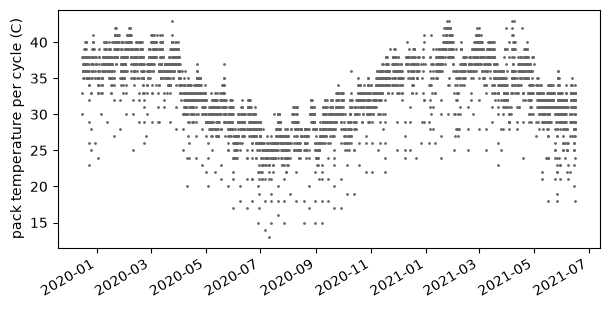

In [4]:
one = frame[frame['unit'] == 'FB-0']
ax = one['maxtemperature'].plot(style='.', color='0.4', markersize=2, figsize=(7, 3.5))
ax.set_xlabel('')
ax.set_ylabel('pack temperature per cycle (C)')
plt.show()

Pack FB-0's per-cycle temperature follows a seasonal pattern, warmer from November to April than in summer.